In [2]:
# libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

from matplotlib.pyplot import figure
from matplotlib.lines import Line2D

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 8)

In [ ]:
# reading data
df = pd.read_csv(
    r'../data/df_company_sizes.csv'
)

In [4]:
# adding work mode label
df['work_mode_lb'] = df['work_mode'].map(
    {
        'Remote': 'Flexible',
        'Hybrid': 'Flexible',
        'On-site': 'Non-Flexible'
    }
)

print(df['work_mode_lb'].value_counts())

work_mode_lb
Non-Flexible    52578
Flexible        17589
Name: count, dtype: int64


In [5]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,70167.000000,70167.000000,7.016700e+04,70167.000000,70167.000000
mean,35083.000000,2024.422649,1.555898e+05,144722.529209,24.836462
std,20255.612506,0.723218,2.877840e+05,64870.634852,43.072948
min,0.000000,2020.000000,1.400000e+04,15000.000000,0.000000
25%,17541.500000,2024.000000,9.520000e+04,95000.000000,0.000000
50%,35083.000000,2025.000000,1.374000e+05,136700.000000,0.000000
75%,52624.500000,2025.000000,1.871615e+05,185851.500000,50.000000
max,70166.000000,2025.000000,3.040000e+07,340300.000000,100.000000


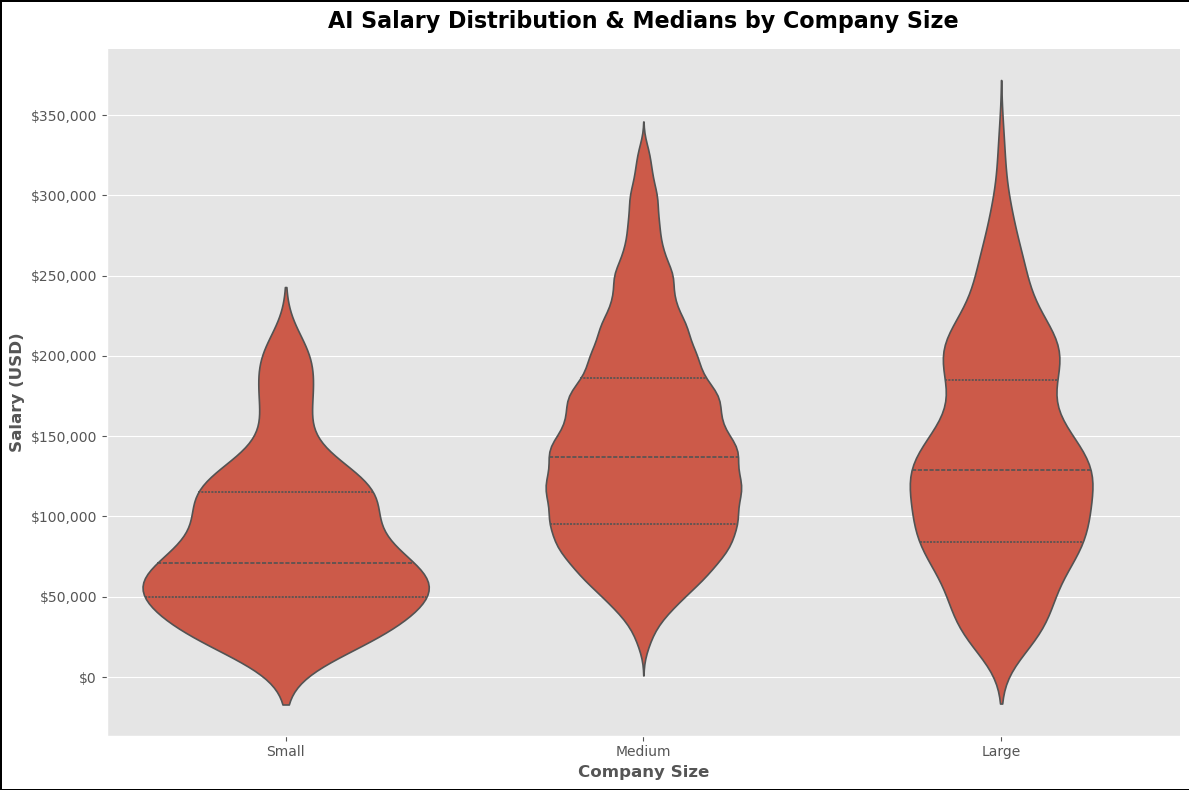

In [6]:
# plot
plot = sns.violinplot(
    data = df,
    x = 'company_size_label',
    y = 'salary_in_usd',
    order = ['Small', 'Medium', 'Large'],
    inner = 'quartile',
    linewidth = 1.2
)

plot.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, loc: f"${int(x):,}"
    )
)

plot.figure.patch.set_linewidth(1)
plot.figure.patch.set_edgecolor('black')

plt.title('AI Salary Distribution & Medians by Company Size', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Company Size', fontsize = 12, fontweight = 'bold')
plt.ylabel('Salary (USD)', fontsize = 12, fontweight = 'bold')

sns.despine()

plt.tight_layout()

plt.savefig(
    'company_size_gc.png',
    edgecolor = plot.figure.get_edgecolor(),
    facecolor = plot.figure.get_facecolor()
)

plt.show()

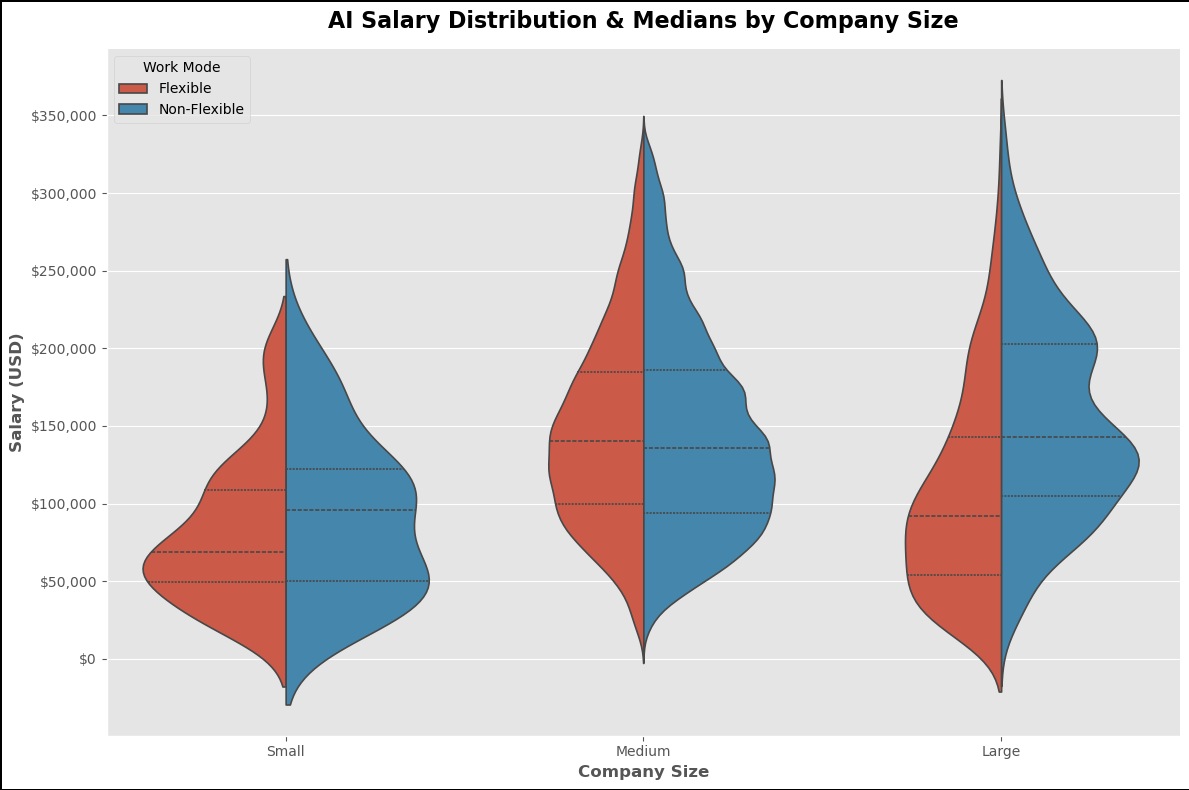

In [7]:
# plot
plot = sns.violinplot(
    data = df,
    x = 'company_size_label',
    y = 'salary_in_usd',
    order = ['Small', 'Medium', 'Large'],
    inner = 'quartile',
    hue = 'work_mode_lb',
    split = True,
    linewidth = 1.2
)

plot.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, loc: f"${int(x):,}"
    )
)

plot.figure.patch.set_linewidth(1)
plot.figure.patch.set_edgecolor('black')

plt.title('AI Salary Distribution & Medians by Company Size', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Company Size', fontsize = 12, fontweight = 'bold')
plt.ylabel('Salary (USD)', fontsize = 12, fontweight = 'bold')

plt.legend(title = 'Work Mode', loc = 'upper left', frameon = True)

sns.despine()

plt.tight_layout()

plt.savefig(
    r'plots/company_size_gc_flexible.png',
    edgecolor = plot.figure.get_edgecolor(),
    facecolor = plot.figure.get_facecolor()
)

plt.show()

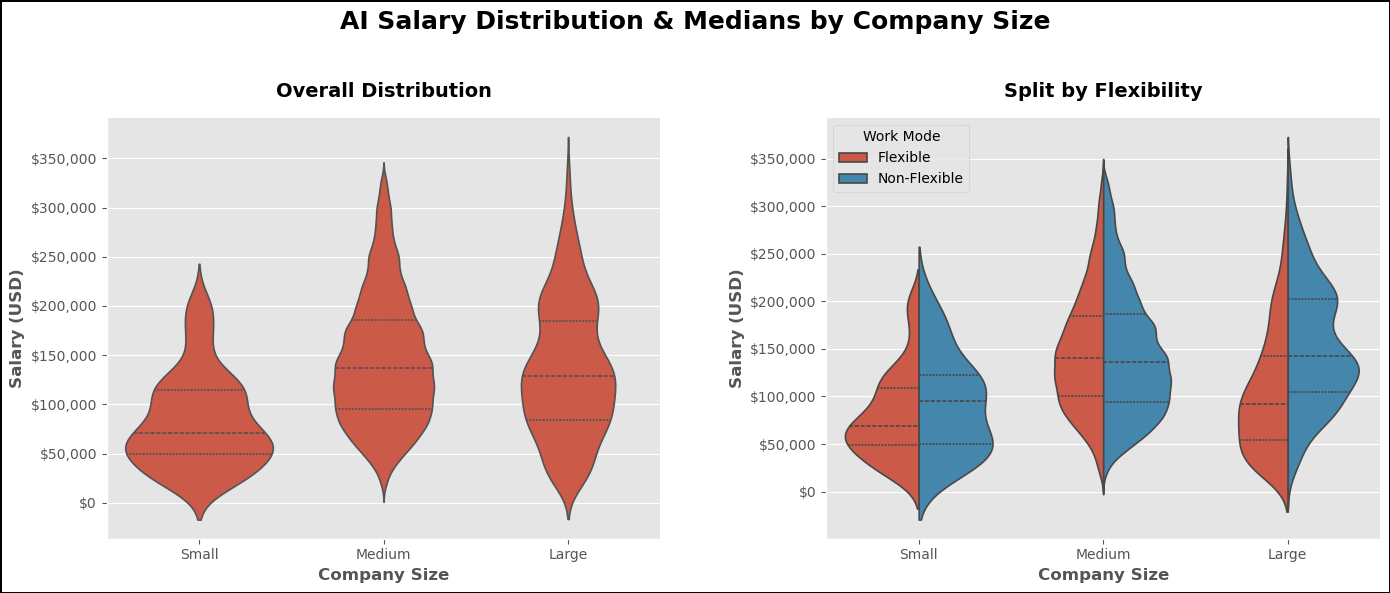

In [35]:
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

sns.violinplot(
    data = df,
    x = 'company_size_label',
    y = 'salary_in_usd',
    order = ['Small', 'Medium', 'Large'],
    inner = 'quartile',
    linewidth = 1.2,
    ax = axes[0]
)

axes[0].set_title('Overall Distribution', fontsize = 14, fontweight = 'bold', pad = 15)
axes[0].set_xlabel('Company Size', fontsize = 12, fontweight = 'bold')
axes[0].set_ylabel('Salary (USD)', fontsize = 12, fontweight = 'bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))

sns.violinplot(
    data = df,
    x = 'company_size_label',
    y = 'salary_in_usd',
    order = ['Small', 'Medium', 'Large'],
    inner = 'quartile',
    hue = 'work_mode_lb',
    split = True,
    linewidth = 1.2,
    ax = axes[1]
)

axes[1].set_title('Split by Flexibility', fontsize = 14, fontweight = 'bold', pad = 15)
axes[1].set_xlabel('Company Size', fontsize = 12, fontweight = 'bold')
axes[1].set_ylabel('Salary (USD)', fontsize = 12, fontweight = 'bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))
axes[1].legend(title = 'Work Mode', loc = 'upper left', frameon = True)

fig.suptitle('AI Salary Distribution & Medians by Company Size', fontsize=18, fontweight='bold')

fig.patch.set_linewidth(1)
fig.patch.set_edgecolor('black')

sns.despine()
plt.tight_layout(rect = [0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.3)

plt.savefig(
    r'plots/company_size_gc_flexible.png',
    edgecolor = plot.figure.get_edgecolor(),
    facecolor = plot.figure.get_facecolor()
)

plt.show()